In [1]:
# ╔═════════════════════════════════╗
# ║  Cell 1 – Imports, Enums, Config ║
# ╚═════════════════════════════════╝
from __future__ import annotations

from dataclasses import dataclass
from enum import Enum, auto
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scnn.optimize import optimize            # ← your SCNN package
from scnn.regularizers import NeuronGL1


# ── type-safe selector flags ──────────────────────────────────────────
class Formulation(str, Enum):
    BASIC_RELU = "basic_relu"
    GATED_RELU = "gated_relu"

class LossType(str, Enum):
    MSE    = "mse"
    HUBER  = "huber"
    PINBALL = "pinball"          # future quantile work

class Device(str, Enum):
    CPU  = "cpu"
    CUDA = "cuda"
    MPS  = "mps"


# ── hyper-parameters & IO ─────────────────────────────────────────────
@dataclass
class Config:
    tickers: List[str] = ("AAPL", "MSFT", "GOOG")
    prediction_cols: List[str] = ("log_ret", "sigma20", "Volume")
    split_date: str = "2018-01-02"
    p_lags: int = 32
    huber_delta: float = 0.10
    lam_gl1: float = 10e-5
    max_neurons: int = 512
    device: Device = Device.CPU
    formulation: Formulation = Formulation.GATED_RELU
    loss_type: LossType = LossType.HUBER
    data_dir: Path = Path(".")
    file_template: str = "{tkr}_2005_2021_clean.csv"


CFG = Config()

In [2]:
# ╔═════════════════════════════════╗
# ║  Cell 2 – Scaling / Un-scaling   ║
# ╚═════════════════════════════════╝
def minmax_scale(
    series: pd.Series, split_idx: int
) -> Tuple[pd.Series, float, float]:
    """Min–max scale *using only training data* up to `split_idx`."""
    s_min = float(series.iloc[:split_idx].min())
    s_max = float(series.iloc[:split_idx].max())
    scaled = (series - s_min) / (s_max - s_min)
    return scaled, s_min, s_max


def build_unscalers(col_stats: Dict[str, Tuple[float, float]]):
    """Return lambdas keyed by column that undo the min-max scale."""
    return {
        col: (lambda x, lo=lo, hi=hi: x * (hi - lo) + lo)
        for col, (lo, hi) in col_stats.items()
    }

In [3]:
# ╔═════════════════════════════════╗
# ║  Helpers – flatten & loader      ║
# ╚═════════════════════════════════╝
from pathlib import Path
from typing import Dict, Tuple, Callable

import numpy as np
import pandas as pd

# --- 1. flatten rule ---------------------------------------------------
def _flatten(col_tup: Tuple) -> str:
    """
    Return the first non-blank, non-'Unnamed', non-ticker element
    from a MultiIndex tuple; strip whitespace.
    """
    for lvl in col_tup:
        s = str(lvl).strip()
        if s and not s.lower().startswith("unnamed") and s != "nan":
            return s
    # Fallback: join all levels with underscore
    return "_".join(str(lvl).strip() for lvl in col_tup if str(lvl) != "nan")


# --- 2. prepare_from_csv ----------------------------------------------
def prepare_from_csv(
    file_path: Path,
    cfg: Config = CFG,
) -> Tuple[
    np.ndarray,                         # X_train
    np.ndarray,                         # X_test
    Dict[str, Tuple[np.ndarray, np.ndarray]],  # tgt_dict
    pd.DatetimeIndex,                   # idx_test
    Dict[str, Callable[[np.ndarray], np.ndarray]],  # unscalers
    Dict[str, np.ndarray],              # seasonality factors
]:
    """
    Load vendor CSV → flatten header → verify cols → seasonality-normalise
    Volume → min–max scale → lag features.

    Returns a 6-tuple, adding a `seasonality` dict that contains the
    rolling-median scale factor for Volume (or empty dict if Volume not
    requested).
    """
    # -------- read & flatten -----------------------------------------
    df = pd.read_csv(file_path, header=[0, 1], index_col=0, parse_dates=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [_flatten(t) for t in df.columns]
    df.index = df.index.normalize()

    # -------- verify --------------------------------------------------
    req = list(cfg.prediction_cols)
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise KeyError(f"{file_path.name}: missing columns {missing}")

    split_idx = df.index.get_loc(pd.to_datetime(cfg.split_date))

    seasonality: Dict[str, np.ndarray] = {}

    # -------- Volume seasonality -------------------------------------
    if "Volume" in req:
        roll = df["Volume"].shift(1).rolling(30, min_periods=1).median()
        df["Volume"] = df["Volume"] / roll
        seasonality["Volume"] = roll  # keep full vector for later

    # -------- min–max scale ------------------------------------------
    col_stats = {}
    for col in req:
        series = df[col]
        lo = float(series.iloc[:split_idx].min())
        hi = float(series.iloc[:split_idx].max())
        df[col] = (series - lo) / (hi - lo)
        col_stats[col] = (lo, hi)

    df = df[req].dropna()

    # -------- lag matrices -------------------------------------------
    X, targets = [], {c: [] for c in req}
    for i in range(cfg.p_lags, len(df)):
        X.append(df.iloc[i - cfg.p_lags : i].values.flatten())
        for col in req:
            targets[col].append(df.iloc[i][col])

    X = np.asarray(X)
    rel_split = split_idx - cfg.p_lags
    X_train, X_test = X[:rel_split], X[rel_split:]

    tgt_dict = {
        col: (np.asarray(vals[:rel_split]), np.asarray(vals[rel_split:]))
        for col, vals in targets.items()
    }

    unscalers = {
        col: (lambda x, lo=lo, hi=hi: x * (hi - lo) + lo)
        for col, (lo, hi) in col_stats.items()
    }

    idx_test = df.index[cfg.p_lags :][rel_split:]
    # align seasonality slice to test index
    if "Volume" in seasonality:
        seasonality["Volume"] = seasonality["Volume"].loc[idx_test].values

    return X_train, X_test, tgt_dict, idx_test, unscalers, seasonality

In [4]:
# ╔═════════════════════════════════╗
# ║  Cell 4 – Train One Target       ║
# ╚═════════════════════════════════╝
def train_one_target(
    X_tr: np.ndarray,
    X_te: np.ndarray,
    y_tr: np.ndarray,
    y_te: np.ndarray,
    cfg: Config = CFG,
):
    """Fit and evaluate a single SCNN model on a given target."""
    model, _ = optimize(
        formulation=cfg.formulation,             # ← Enum
        max_neurons=cfg.max_neurons,
        X_train=X_tr,
        y_train=y_tr,
        X_test=X_te,
        y_test=y_te,
        bias=True,
        loss_type=cfg.loss_type,                 # ← Enum
        huber_delta=cfg.huber_delta,
        regularizer=NeuronGL1(cfg.lam_gl1),
        verbose=False,
        device=cfg.device,                       # ← Enum
    )
    preds_tr, preds_te = model(X_tr), model(X_te)
    return {
        "train_mse": float(((preds_tr - y_tr) ** 2).mean()),
        "test_mse": float(((preds_te - y_te) ** 2).mean()),
        "model": model,
        "preds_test": preds_te.ravel(),
    }


In [5]:
pd.read_csv("AAPL_2005_2021_clean.csv", header=[0, 1], nrows=0).columns.to_list()

[('Price', 'Ticker'),
 ('Adj Close', 'AAPL'),
 ('Close', 'AAPL'),
 ('High', 'AAPL'),
 ('Low', 'AAPL'),
 ('Open', 'AAPL'),
 ('Volume', 'AAPL'),
 ('log_ret', 'Unnamed: 7_level_1'),
 ('sigma20', 'Unnamed: 8_level_1'),
 ('TurnUSD', 'Unnamed: 9_level_1')]

In [6]:
# ╔═════════════════════════════════╗
# ║  Cell 5 – Per-ticker Training   ║
# ╚═════════════════════════════════╝
results = {}

for tkr in CFG.tickers:
    path = CFG.data_dir / CFG.file_template.format(tkr=tkr)
    X_tr, X_te, tgt_dict, idx_test, unscalers, seasonality = prepare_from_csv(
        path, cfg=CFG
    )

    print(f"\nTicker: {tkr}")
    for col, (y_tr, y_te) in tgt_dict.items():
        res = train_one_target(X_tr, X_te, y_tr, y_te, cfg=CFG)

        # add seasonality factor (None for non-volume cols)
        vol_seas = seasonality["Volume"] if col == "Volume" else None

        results[(tkr, col)] = {
            **res,
            "index": idx_test,
            "unscale": unscalers[col],
            "seasonality": vol_seas,
        }

        print(
            f"  {col:8s}  MSE train={res['train_mse']:.4e}  "
            f"test={res['test_mse']:.4e}"
        )


Ticker: AAPL
  log_ret   MSE train=6.9300e-03  test=6.2997e-03
  sigma20   MSE train=2.7366e-02  test=3.0947e-02
  Volume    MSE train=7.5885e-03  test=6.2151e-03

Ticker: MSFT
  log_ret   MSE train=3.7031e-03  test=4.4870e-03
  sigma20   MSE train=3.2357e-02  test=4.8682e-02
  Volume    MSE train=2.7059e-03  test=1.4545e-03

Ticker: GOOG
  log_ret   MSE train=4.1500e-03  test=3.9526e-03
  sigma20   MSE train=4.4870e-02  test=3.8007e-02
  Volume    MSE train=6.1413e-03  test=4.2093e-03


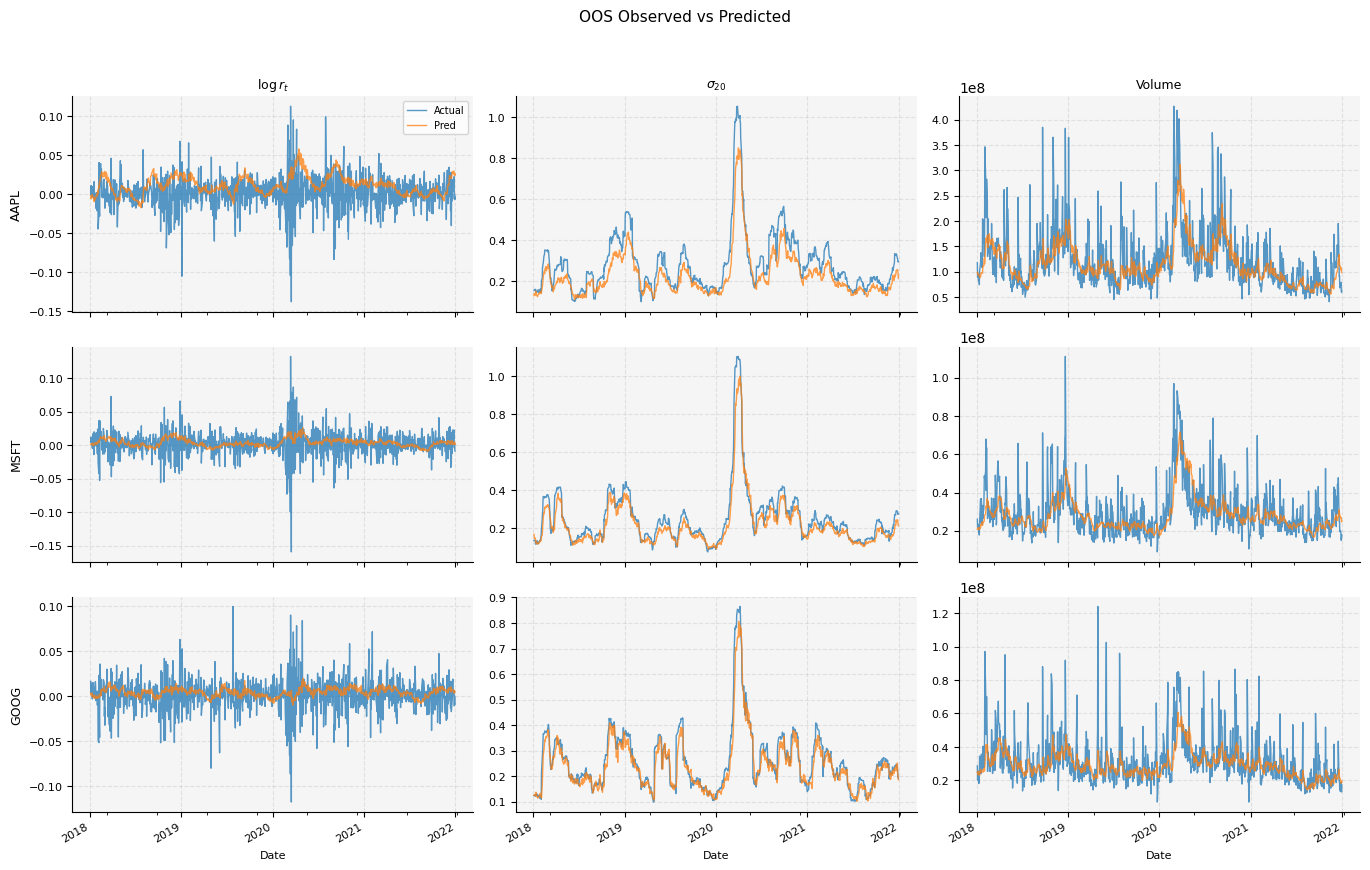

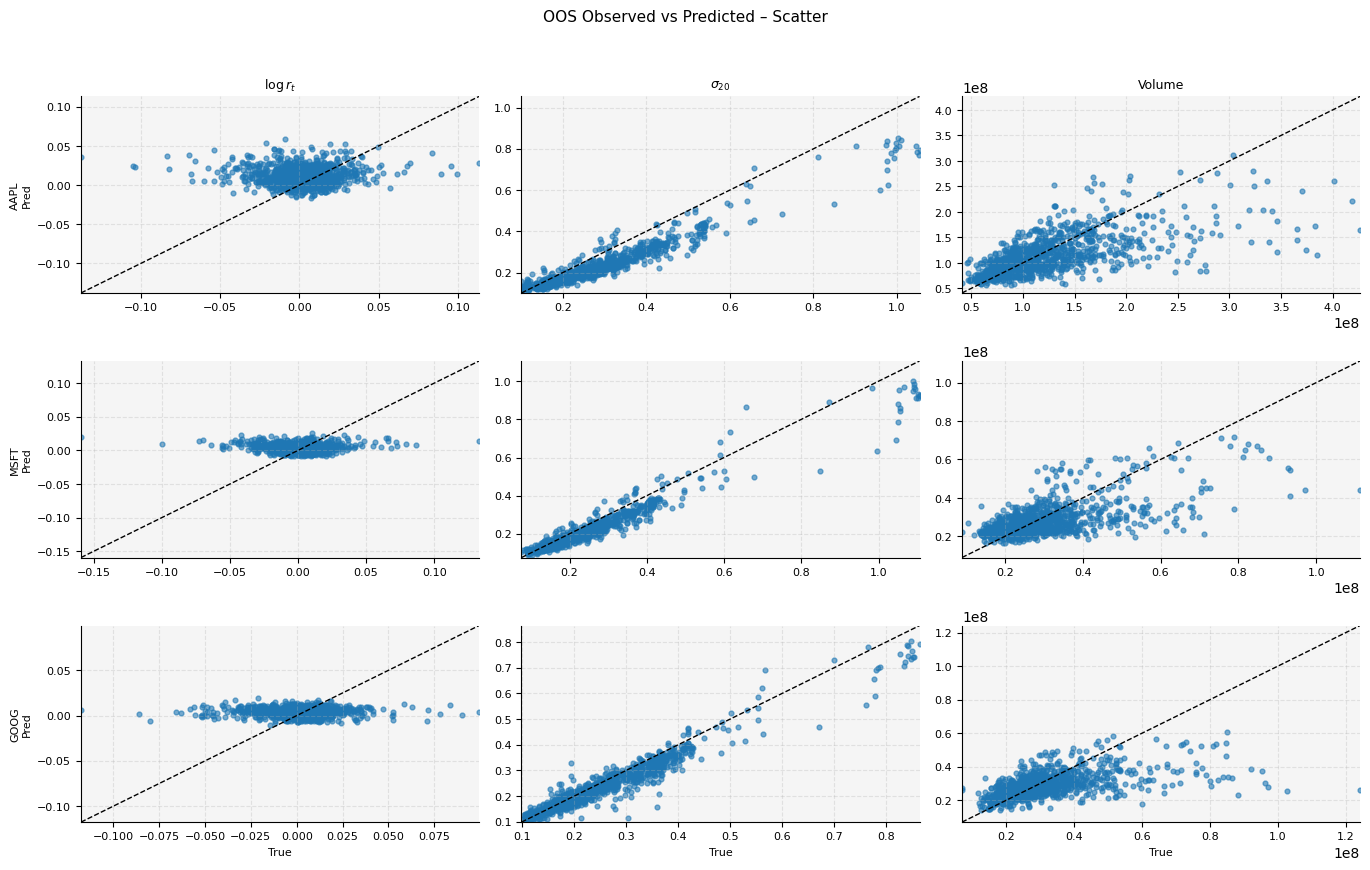

In [7]:
# ╔═════════════════════════════════════════════════════════════════╗
# ║  Plot – OOS Overlay + Scatter (σ₍₂₀₎ label fixed)              ║
# ╚═════════════════════════════════════════════════════════════════╝
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── pretty names for each target --------------------------------------
display = {
    "log_ret": r"$\log r_t$",
    "sigma20": r"$\sigma_{20}$",
    "Volume":  "Volume",
}

# ── helper -------------------------------------------------------------
def style_axes(ax, *, bottom: bool = False, xlabel: str | None = None) -> None:
    ax.set_facecolor("#f5f5f5")
    ax.grid(True, ls="--", alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    if bottom and xlabel:
        ax.set_xlabel(xlabel, fontsize=8)

# ── build tidy long DF -------------------------------------------------
frames: list[pd.DataFrame] = []
for tkr in CFG.tickers:
    raw = (
        pd.read_csv(
            CFG.data_dir / CFG.file_template.format(tkr=tkr),
            header=[0, 1],
            index_col=0,
            parse_dates=True,
        ).rename(columns=str.strip)
    )
    raw.index = raw.index.normalize()

    for col in CFG.prediction_cols:
        key     = (tkr, col)
        idx     = results[key]["index"]
        unscale = results[key]["unscale"]

        true_1d = np.asarray(raw.loc[idx, col]).ravel()
        pred_1d = np.asarray(unscale(results[key]["preds_test"])).ravel()
        if col == "Volume":
            pred_1d *= results[key]["seasonality"]

        frames.append(
            pd.DataFrame(
                {
                    "date":   idx.astype("datetime64[ns]"),
                    "true":   true_1d,
                    "pred":   pred_1d,
                    "ticker": tkr,
                    "col":    col,
                }
            )
        )

merged = pd.concat(frames, ignore_index=True)

# ── Panel A – overlay --------------------------------------------------
n_row, n_col = len(CFG.tickers), len(CFG.prediction_cols)
fig_ts, axes = plt.subplots(
    n_row, n_col,
    figsize=(4.6 * n_col, 2.9 * n_row),
    sharex=True,
)

year_fmt = mdates.DateFormatter("%Y")
year_loc = mdates.YearLocator()

for i, tkr in enumerate(CFG.tickers):
    for j, col in enumerate(CFG.prediction_cols):
        ax = axes[i, j]
        sub = (
            merged.query("ticker == @tkr and col == @col")
            .set_index("date")
            .sort_index()
        )
        sub["true"].plot(ax=ax, label="Actual", alpha=0.75, lw=1)
        sub["pred"].plot(ax=ax, label="Pred",   alpha=0.75, lw=1)

        if i == 0:
            ax.set_title(display.get(col, col), fontsize=9)   # <<<<<<
        if j == 0:
            ax.set_ylabel(tkr, fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

        ax.xaxis.set_major_locator(year_loc)
        ax.xaxis.set_major_formatter(year_fmt)
        style_axes(ax, bottom=(i == n_row - 1), xlabel="Date")

fig_ts.autofmt_xdate()
fig_ts.suptitle("OOS Observed vs Predicted", y=0.995, fontsize=11)
fig_ts.tight_layout(rect=[0, 0, 1, 0.97])

# ── Panel B – scatter --------------------------------------------------
fig_sc, axes_sc = plt.subplots(
    n_row, n_col,
    figsize=(4.6 * n_col, 2.9 * n_row),
)

for i, tkr in enumerate(CFG.tickers):
    for j, col in enumerate(CFG.prediction_cols):
        ax  = axes_sc[i, j]
        sub = merged.query("ticker == @tkr and col == @col")
        x, y = sub["true"], sub["pred"]

        ax.scatter(x, y, s=12, alpha=0.6)
        lim = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lim, lim, "k--", lw=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)

        if i == 0:
            ax.set_title(display.get(col, col), fontsize=9)   # <<<<<<
        if j == 0:
            ax.set_ylabel(tkr, fontsize=9)

        style_axes(ax, bottom=(i == n_row - 1))
        if i == n_row - 1:
            ax.set_xlabel("True", fontsize=8)
        if j == 0:
            ax.set_ylabel(f"{tkr}\nPred", fontsize=8)

fig_sc.suptitle("OOS Observed vs Predicted – Scatter", y=0.995, fontsize=11)
fig_sc.tight_layout(rect=[0, 0, 1, 0.97])

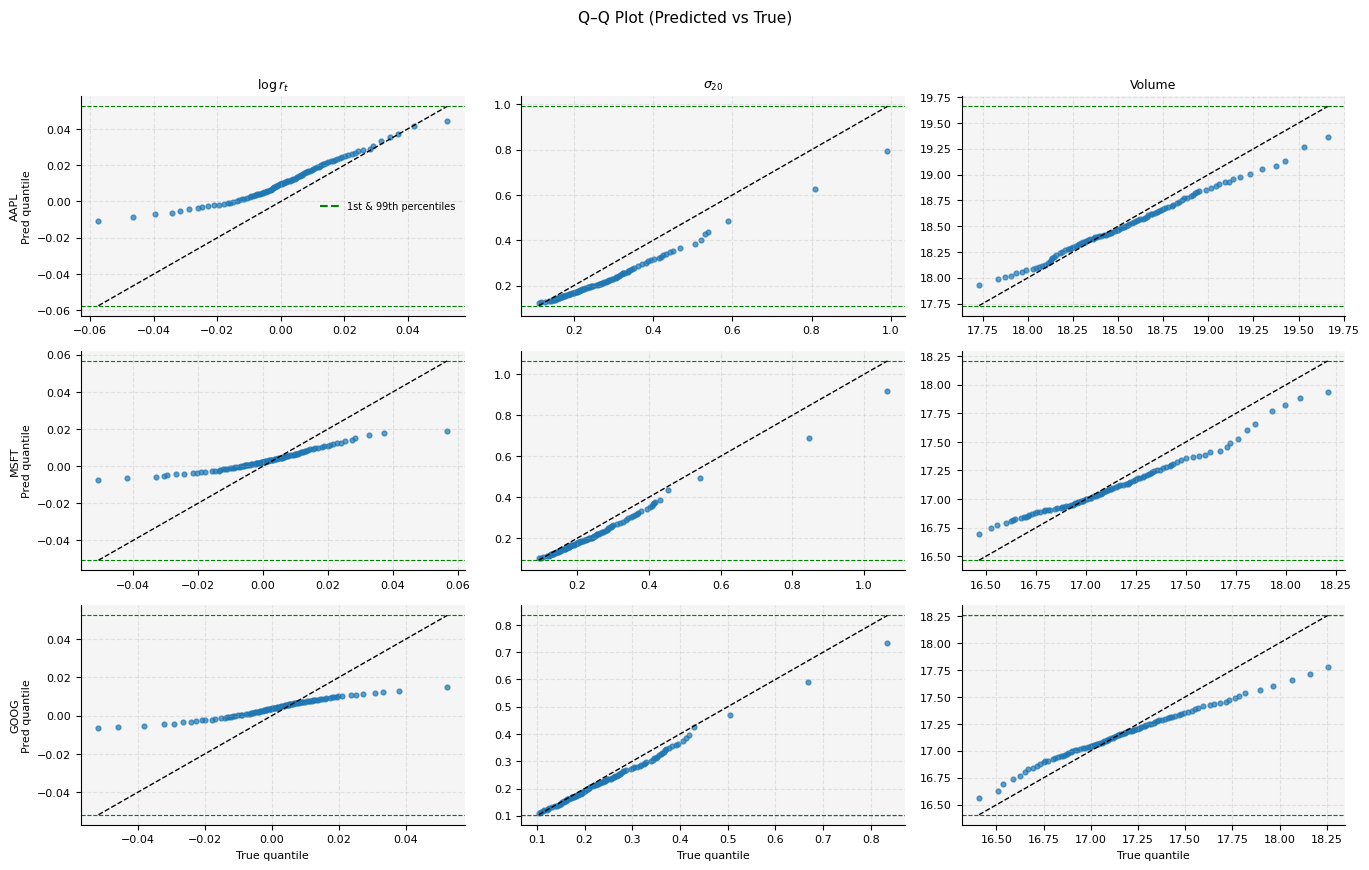

In [8]:
# ╔═════════════════════════════════╗
# ║  Cell – Q-Q plots + percentile  ║
# ╚═════════════════════════════════╝
import matplotlib.pyplot as plt
import numpy as np

fig_qq, axes_qq = plt.subplots(
    len(CFG.tickers),
    len(CFG.prediction_cols),
    figsize=(4.6 * len(CFG.prediction_cols), 2.9 * len(CFG.tickers)),
)

for i, tkr in enumerate(CFG.tickers):
    for j, col in enumerate(CFG.prediction_cols):
        ax = axes_qq[i, j]
        sub = merged.query("ticker == @tkr and col == @col")
        true_vals = sub["true"].values
        pred_vals = sub["pred"].values

        # optional log transform for Volume
        if col == "Volume":
            true_vals = np.log1p(true_vals)
            pred_vals = np.log1p(pred_vals)

        # percentile guide lines (true distribution)
        p_low, p_high = np.quantile(true_vals, [0.01, 0.99])
        ax.axhline(p_low,  color="g", ls="--", lw=0.8)
        ax.axhline(p_high, color="g", ls="--", lw=0.8)

        # Q–Q scatter
        q = np.linspace(0.01, 0.99, 100)
        ax.scatter(
            np.quantile(true_vals, q),
            np.quantile(pred_vals, q),
            s=12, alpha=0.7,
        )
        ax.plot(np.quantile(true_vals, q), np.quantile(true_vals, q), "k--", lw=1)

        # titles & labels
        if i == 0:
            ax.set_title(display.get(col, col), fontsize=9)
        if j == 0:
            ax.set_ylabel(tkr, fontsize=9)
        if i == len(CFG.tickers) - 1:
            ax.set_xlabel("True quantile", fontsize=8)
        if j == 0:
            ax.set_ylabel(f"{tkr}\nPred quantile", fontsize=8)

        # add legend only once (top-left)
        if i == 0 and j == 0:
            ax.plot([], [], ls="--", color="g", label="1st & 99th percentiles")
            ax.legend(fontsize=7, frameon=False)

        style_axes(ax, bottom=(i == len(CFG.tickers) - 1))

fig_qq.suptitle("Q–Q Plot (Predicted vs True)", y=0.995, fontsize=11)
fig_qq.tight_layout(rect=[0, 0, 1, 0.97])

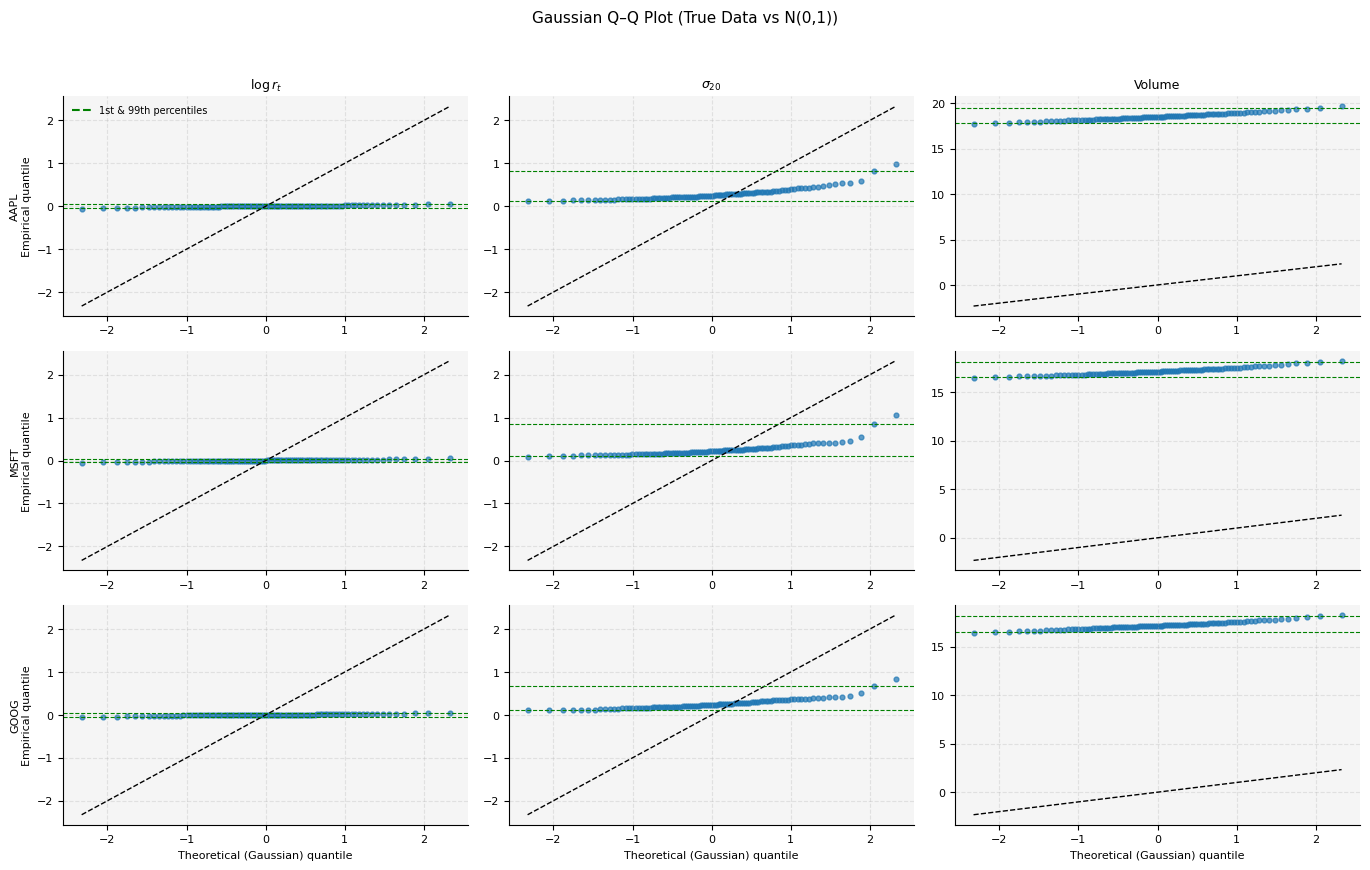

In [9]:
# ╔═════════════════════════════════════════════════════════════════╗
# ║  Cell – Gaussian-reference Q-Q plots (styled)                  ║
# ╚═════════════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

fig_gqq, axes_gqq = plt.subplots(
    len(CFG.tickers),
    len(CFG.prediction_cols),
    figsize=(4.6 * len(CFG.prediction_cols), 2.9 * len(CFG.tickers)),
)

for i, tkr in enumerate(CFG.tickers):
    for j, col in enumerate(CFG.prediction_cols):
        ax = axes_gqq[i, j]
        sub = merged.query("ticker == @tkr and col == @col")
        vals = sub["true"].values  # we compare *true* distribution to Gaussian

        # optional log transform for Volume
        if col == "Volume":
            vals = np.log1p(vals)

        # theoretical (Gaussian) grid & empirical quantiles
        q = np.linspace(0.01, 0.99, 100)
        theo = norm.ppf(q)             # standard-normal quantiles
        emp  = np.quantile(vals, q)

        ax.scatter(theo, emp, s=12, alpha=0.7)
        ax.plot(theo, theo, "k--", lw=1)

        # titles & labels
        if i == 0:
            ax.set_title(display.get(col, col), fontsize=9)
        if j == 0:
            ax.set_ylabel(tkr, fontsize=9)

        if i == len(CFG.tickers) - 1:
            ax.set_xlabel("Theoretical (Gaussian) quantile", fontsize=8)
        if j == 0:
            ax.set_ylabel(f"{tkr}\nEmpirical quantile", fontsize=8)

        # percentile guide lines at 1 % & 99 % of empirical
        p_low, p_high = np.quantile(emp, [0.01, 0.99])
        ax.axhline(p_low,  color="g", ls="--", lw=0.8)
        ax.axhline(p_high, color="g", ls="--", lw=0.8)

        # legend only once
        if i == 0 and j == 0:
            ax.plot([], [], ls="--", color="g", label="1st & 99th percentiles")
            ax.legend(fontsize=7, frameon=False)

        style_axes(ax, bottom=(i == len(CFG.tickers) - 1))

fig_gqq.suptitle("Gaussian Q–Q Plot (True Data vs N(0,1))", y=0.995, fontsize=11)
fig_gqq.tight_layout(rect=[0, 0, 1, 0.97])
